# Ensemble

Autor: Bartosz Perz

## Zadanie 1: Salud 2030

Na potrzeby zadania potraktuj dane jako w pełni zebrane od ankietowanych.

### Wprowadzenie

Pracujesz jako Senior Data Scientist w **Secretaría de Salud de México** – meksykańskim Ministerstwie Zdrowia. Rząd Meksyku przeznaczył ogromne fundusze, angażując Cię do pomocy w wywiązaniu się z globalnych zobowiązań wobec ONZ i WHO.

Meksyk, jako sygnatariusz Agendy 2030, kładzie szczególny nacisk na **3. Cel Zrównoważonego Rozwoju (SDG 3): Dobre zdrowie i jakość życia**. Kluczowym elementem tego celu jest **Zadanie 3.4**, które zakłada ograniczenie do 2030 roku o jedną trzecią przedwczesnej umieralności z powodu chorób niezakaźnych (NCDs) poprzez zapobieganie i leczenie.

Jak jednak spełnić to wymaganie? Bierzesz na celownik otyłość – główny czynnik ryzyka wystąpienia chorób układu krążenia, cukrzycy typu 2 i nadciśnienia, które stanowią trzon problemów zdrowotnych wymienionych w SDG 3. Twoim celem jest stworzenie modelu, który na podstawie danych ankietowych zidentyfikuje osoby wymagające interwencji profilaktycznej. Aby pozyskać zbiór danych do uczenia modeli, w wybranych przychodniach przeprowadzono badanie pilotażowe.

Musisz działać precyzyjnie, ponieważ niedokładny model pominie zagrożonych pacjentów, a model zbyt "ciężki" obliczeniowo nie będzie mógł zostać wdrożony w wiejskich przychodniach o ograniczonych zasobach. W Meksyku, gdzie wskaźniki otyłości należą do najwyższych na świecie, Twoja praca nad optymalnym modelem predykcyjnym jest bezpośrednim wkładem w walkę o wydłużenie życia obywateli i redukcję obciążenia systemu ochrony zdrowia.

### Polecenia:

1. **Wykonaj analizę eksploracyjną (EDA)** [zbioru danych dot. otyłości (UCI ID: 544)](https://archive.ics.uci.edu/dataset/544/estimation+of+obesity+levels+based+on+eating+habits+and+physical+condition).
2. **Wyucz modele klasyfikacyjne**. Wykorzystaj bibliotekę `scikit-learn` i zbadaj:

* **Pojedyncze drzewa decyzyjne** i **regresję logistyczną** – jako bazowe modele, łatwe do interpretacji przez lekarza.
* **Bagging:** `BaggingClassifier` z płytkimi drzewami, głębokimi drzewami oraz z regresją logistyczną. Przetestuj wpływ parametrów *n_estimators*, *bootstrap* i *bootstrap_features* na wyniki.
* **Boosting:** `AdaBoost` (przetestuj na płytkich drzewach i regresji logistycznej) oraz `GradientBoosting` (oparty domyślnie na drzewach). Zbadaj relację (trade-off) między parametrami *n_estimators* i *learning_rate*.
* **Stacking & Voting:** skonstruuj kolejny komitet wg własnego uznania (dobierz parametry i modele). Połącz modele o różnej architekturze, by sprawdzić, czy zespół różnych algorytmów daje lepsze efekty niż pojedynczy "ekspert".

3. **Zwaliduj modele** pod kątem wdrożenia krajowego.

* Dobierz miary **skuteczności** modelu adekwatne do problemu.
* Zwróć uwagę na **czas predykcji**.
* Zbadaj **pewność (confidence) modelu**.

4. **Zapisz wnioski dla Ministerstwa Zdrowia.**

Przy realizacji poleceń pamiętaj o charakterze zadania. Który z modeli zarekomendowałbyś do wdrożenia? Czy dokładność modelu jest jedynym wyznacznikiem jego jakości? Czy są modele, których wdrożenie byłoby stratą zasobów publicznych?

In [26]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from ucimlrepo import fetch_ucirepo


obesity_dataset = fetch_ucirepo(id=544)
df = obesity_dataset.data.features.copy()
df['NObeyesdad'] = obesity_dataset.data.targets.values.ravel()
import warnings
warnings.filterwarnings('ignore', category=FutureWarning)


In [2]:
#podstawowa analiza zbioru danych
print(df.head())
print(df.info())
print(df.describe())

   Gender   Age  Height  Weight family_history_with_overweight FAVC  FCVC  \
0  Female  21.0    1.62    64.0                            yes   no   2.0   
1  Female  21.0    1.52    56.0                            yes   no   3.0   
2    Male  23.0    1.80    77.0                            yes   no   2.0   
3    Male  27.0    1.80    87.0                             no   no   3.0   
4    Male  22.0    1.78    89.8                             no   no   2.0   

   NCP       CAEC SMOKE  CH2O  SCC  FAF  TUE        CALC  \
0  3.0  Sometimes    no   2.0   no  0.0  1.0          no   
1  3.0  Sometimes   yes   3.0  yes  3.0  0.0   Sometimes   
2  3.0  Sometimes    no   2.0   no  2.0  1.0  Frequently   
3  3.0  Sometimes    no   2.0   no  2.0  0.0  Frequently   
4  1.0  Sometimes    no   2.0   no  0.0  0.0   Sometimes   

                  MTRANS           NObeyesdad  
0  Public_Transportation        Normal_Weight  
1  Public_Transportation        Normal_Weight  
2  Public_Transportation        

In [3]:
#sprawdzenie brakujących wartości
print(df.isnull().sum())

Gender                            0
Age                               0
Height                            0
Weight                            0
family_history_with_overweight    0
FAVC                              0
FCVC                              0
NCP                               0
CAEC                              0
SMOKE                             0
CH2O                              0
SCC                               0
FAF                               0
TUE                               0
CALC                              0
MTRANS                            0
NObeyesdad                        0
dtype: int64


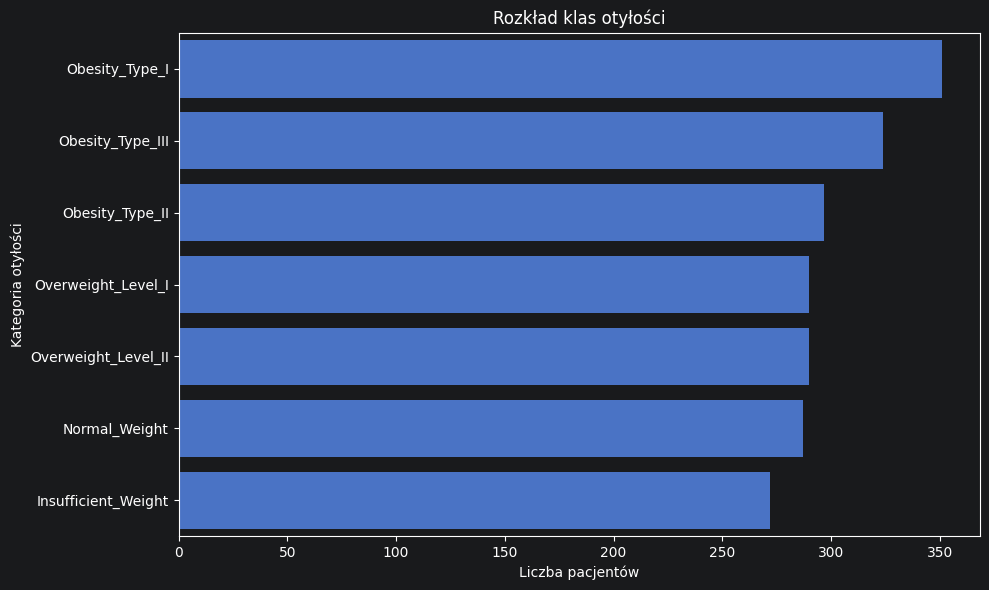

In [4]:
#analiza rozkładu klas
plt.figure(figsize=(10, 6))
sns.countplot(data=df, y='NObeyesdad', order=df['NObeyesdad'].value_counts().index)
plt.title('Rozkład klas otyłości')
plt.xlabel('Liczba pacjentów')
plt.ylabel('Kategoria otyłości')
plt.tight_layout()
plt.show()

| Variable Name | Type | Description | Missing Values |
|---|---|---|---|
| Gender | Kategoryczna |  | nie |
| Age | Ciągła |  | nie |
| Height | Ciągła |  | nie |
| Weight | Ciągła |  | nie |
| family_history_with_overweight | Binarna | Czy ktoś z Twojej rodziny cierpiał lub cierpi na nadwagę? | nie |
| FAVC | Binarna | Czy często jesz wysokokaloryczne jedzenie? | nie |
| FCVC | Całkowita | Czy zwykle jesz warzywa podczas posiłków? | nie |
| NCP | Ciągła | Ile głównych posiłków spożywasz dziennie? | nie |
| CAEC | Kategoryczna | Czy jesz coś pomiędzy posiłkami? | nie |
| SMOKE | Binarna | Czy palisz? | nie |
| CH2O | Ciągła | Ile wody pijesz dziennie? | nie |
| SCC | Binarna | Czy monitorujesz liczbę kalorii spożywanych dziennie? | nie |
| FAF | Ciągła | Jak często uprawiasz aktywność fizyczną? | nie |
| TUE | Całkowita | Ile czasu korzystasz z urządzeń technologicznych, takich jak telefon komórkowy, gry wideo, telewizja, komputer i inne? | nie |
| CALC | Kategoryczna | Jak często pijesz alkohol? | nie |
| MTRANS | Kategoryczna | Z jakiego środka transportu zwykle korzystasz? | nie |
| NObeyesdad | Kategoryczna | Poziom otyłości | nie |

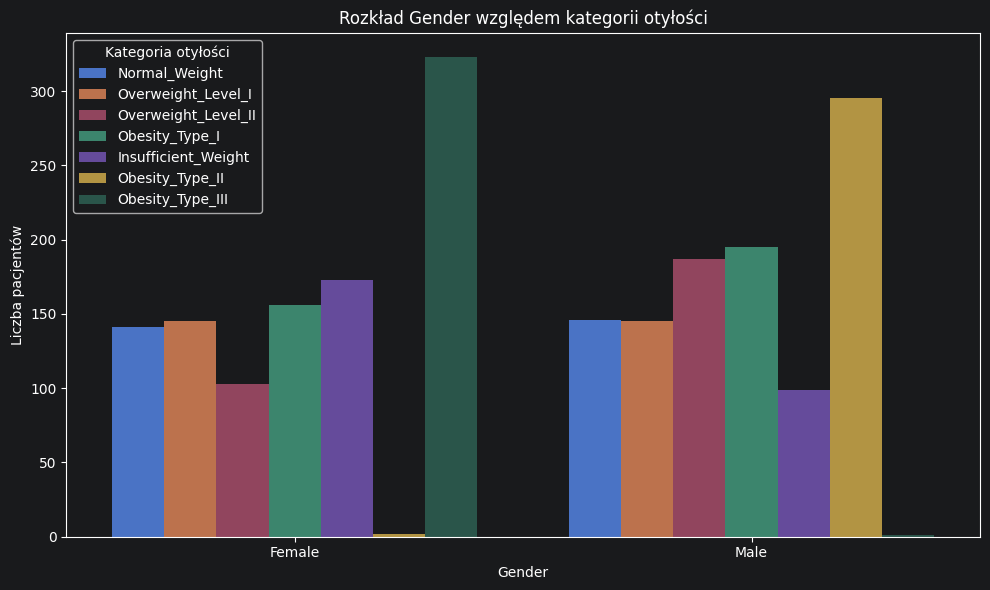

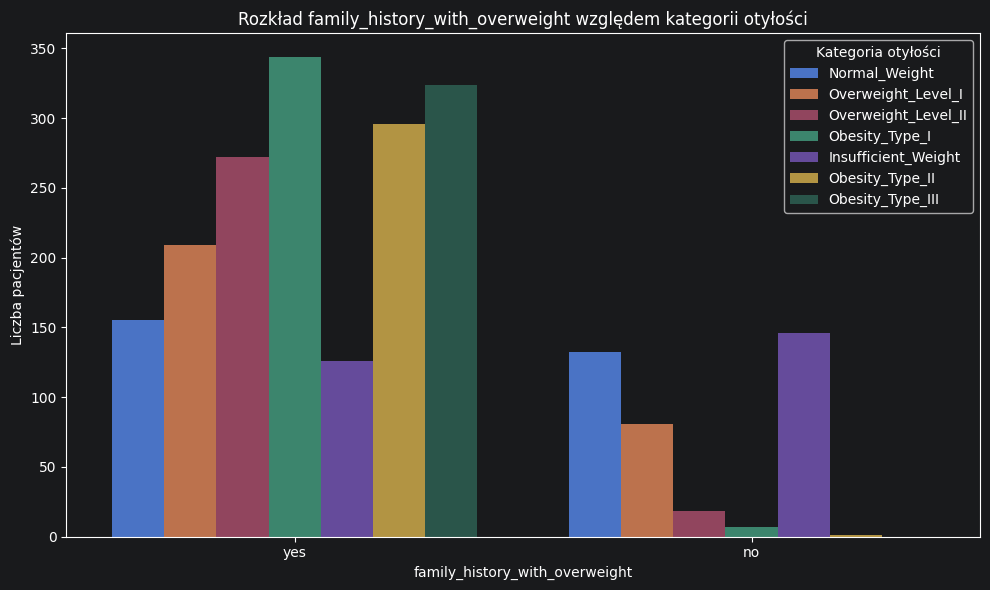

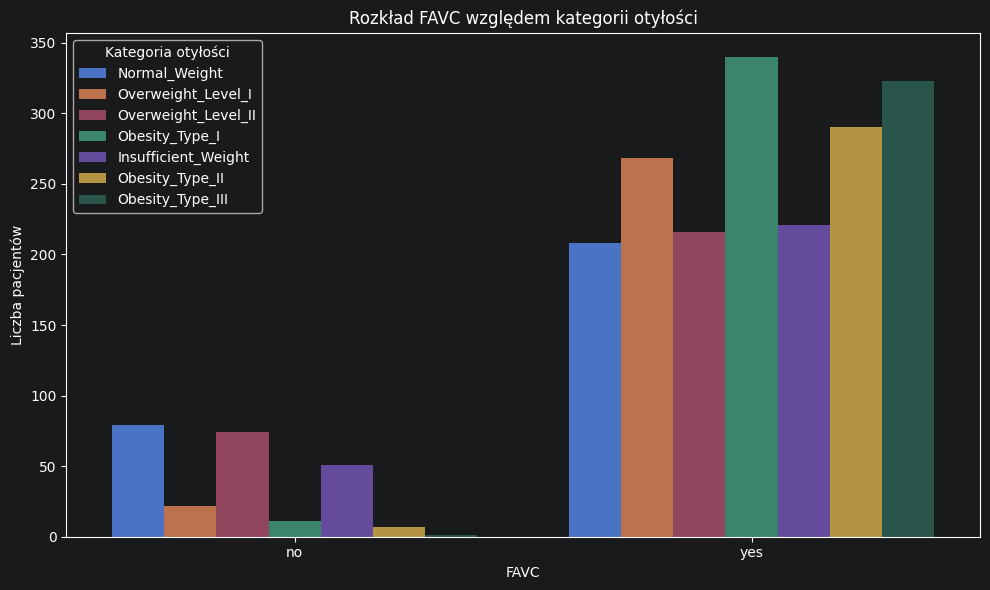

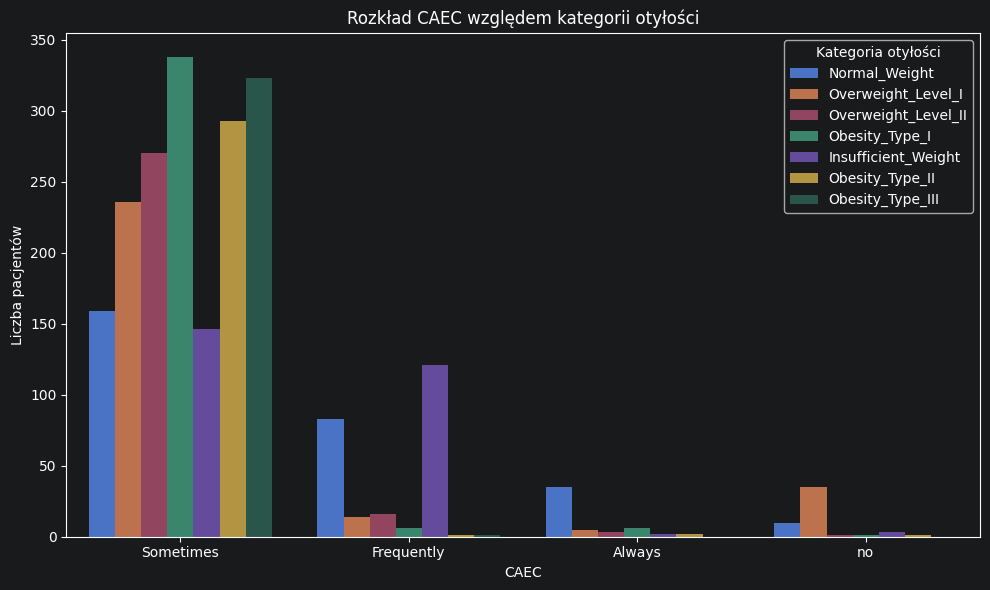

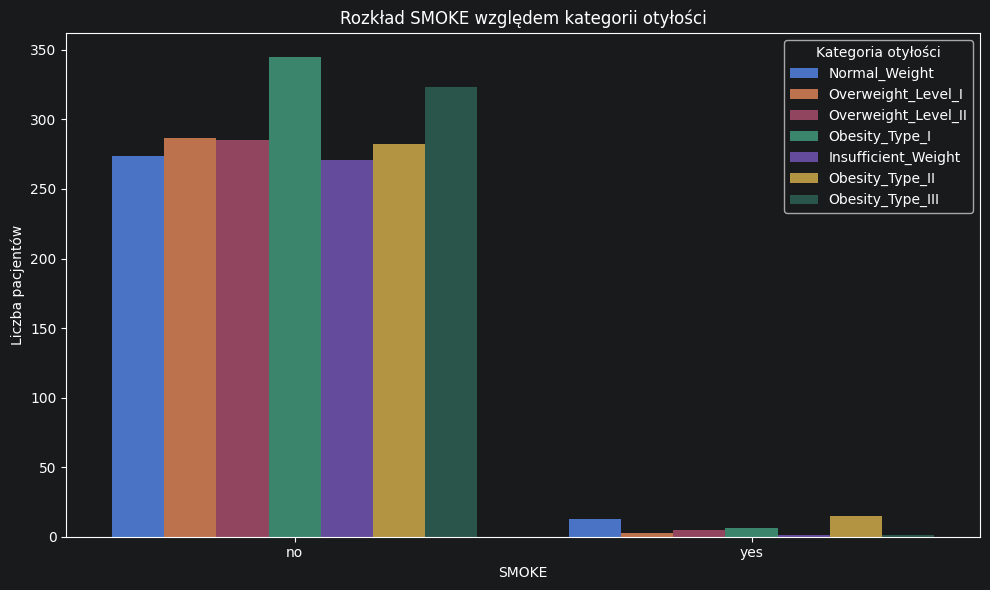

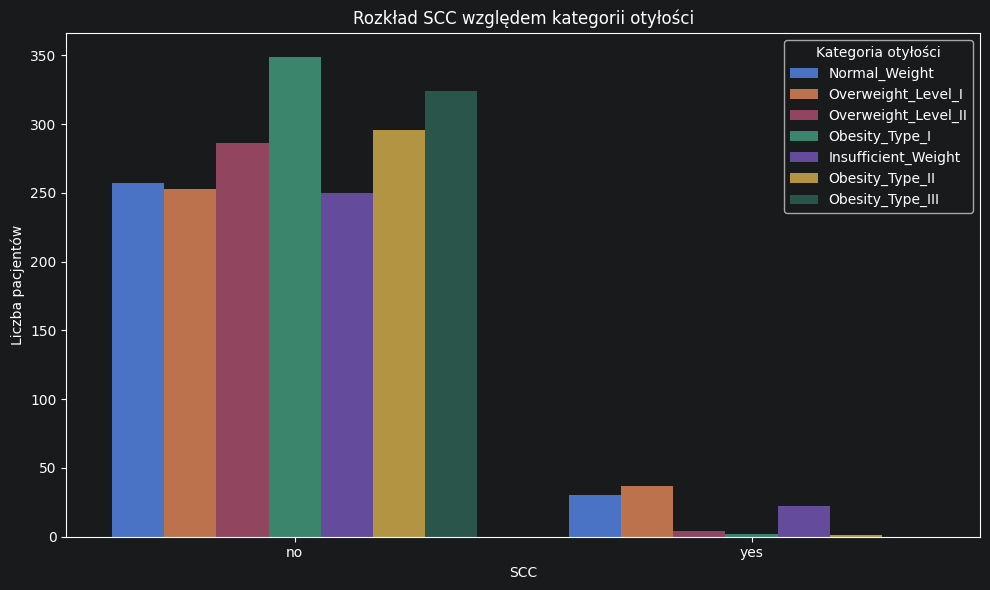

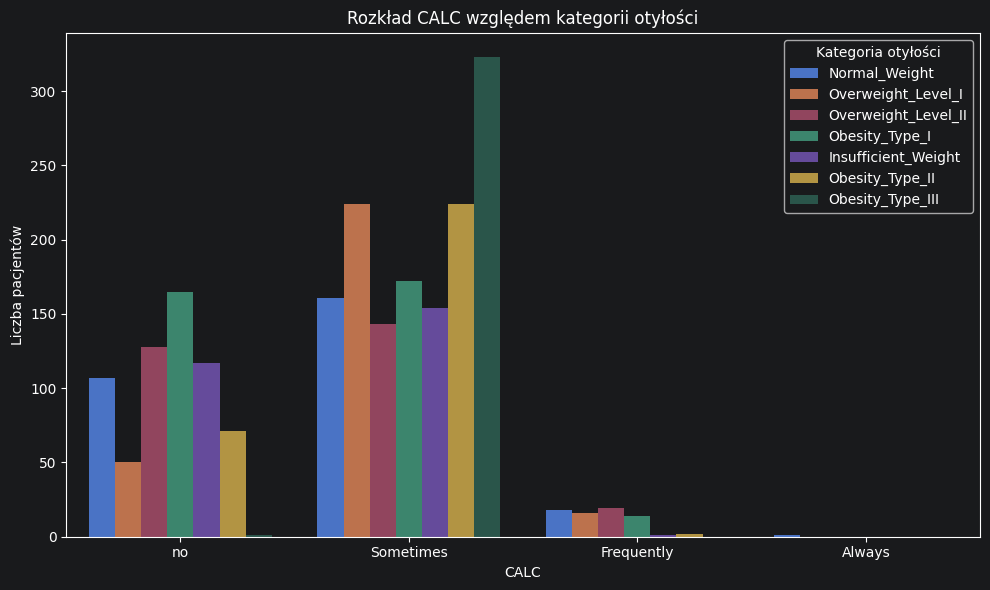

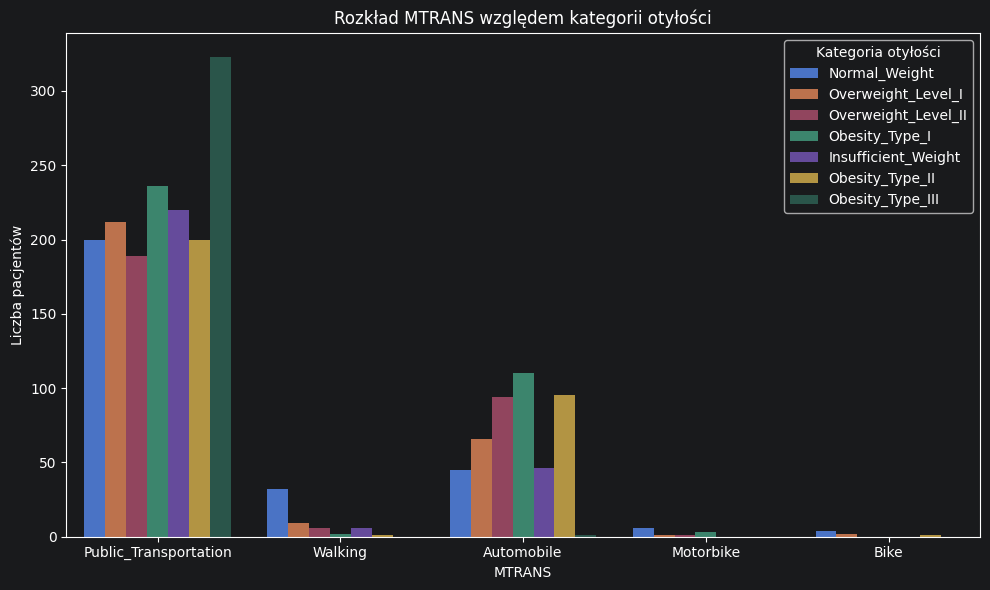

In [5]:
categorical_features = ['Gender', 'family_history_with_overweight', 'FAVC', 'CAEC', 'SMOKE', 'SCC','CALC','MTRANS']
for feature in categorical_features:
    plt.figure(figsize=(10, 6))
    sns.countplot(data=df, x=feature, hue='NObeyesdad')
    plt.title(f'Rozkład {feature} względem kategorii otyłości')
    plt.xlabel(feature)
    plt.ylabel('Liczba pacjentów')
    plt.legend(title='Kategoria otyłości')
    plt.tight_layout()
    plt.show()

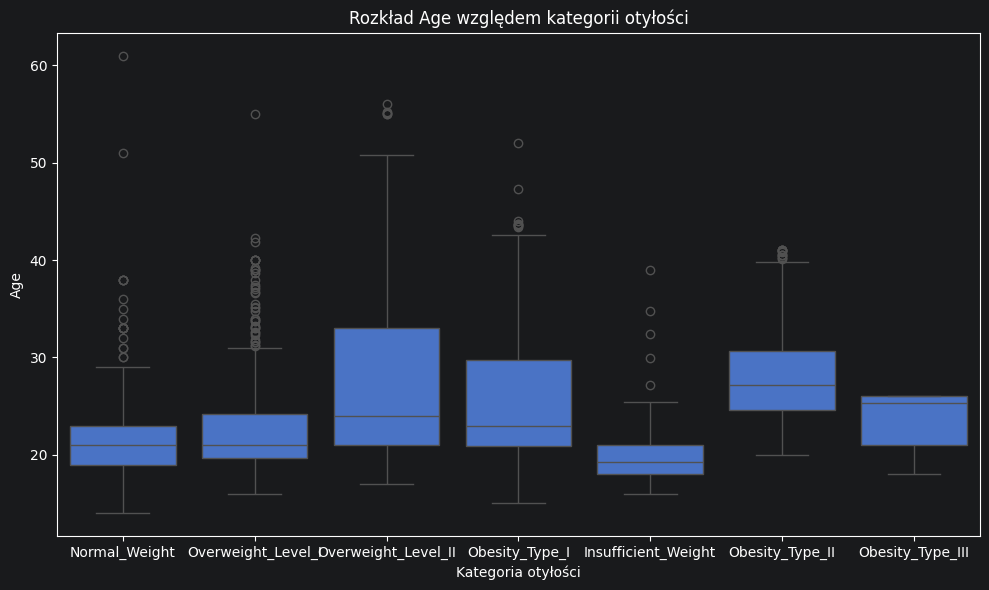

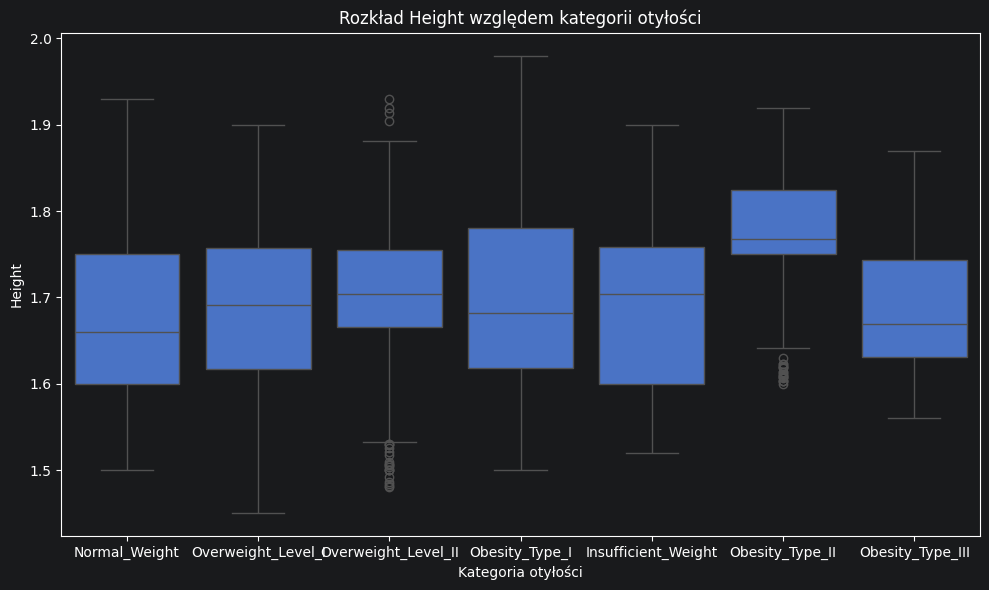

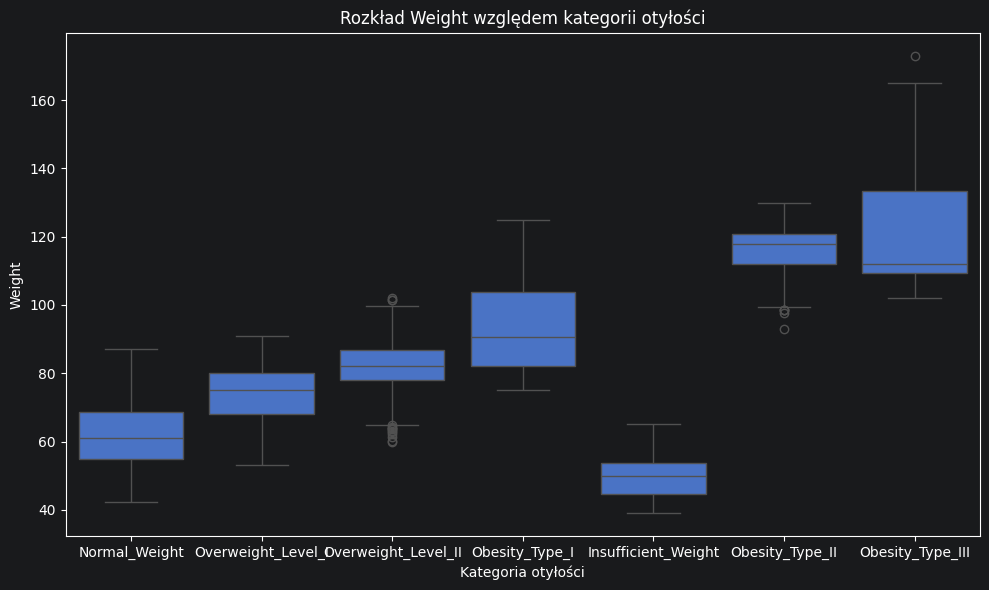

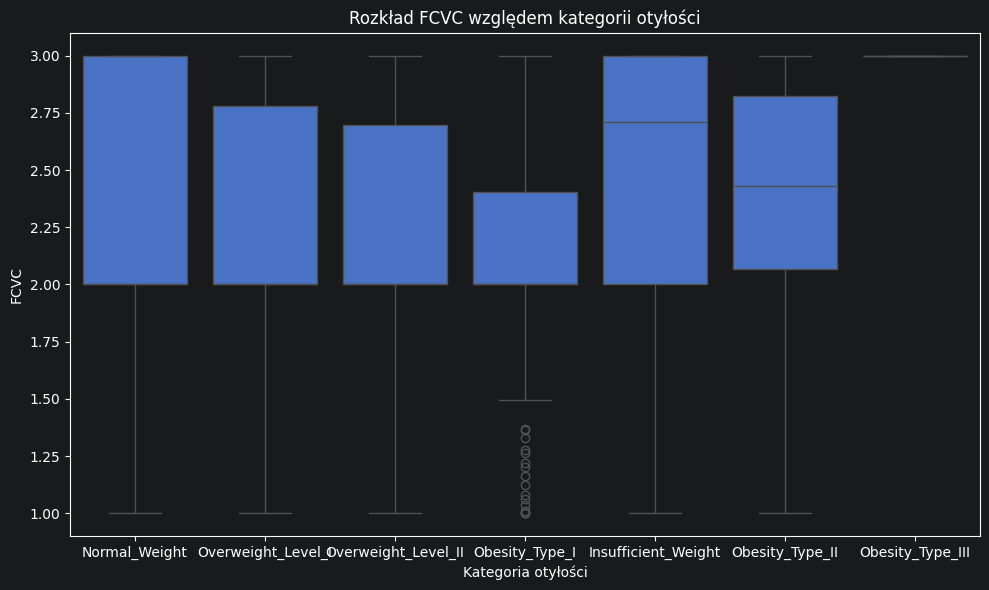

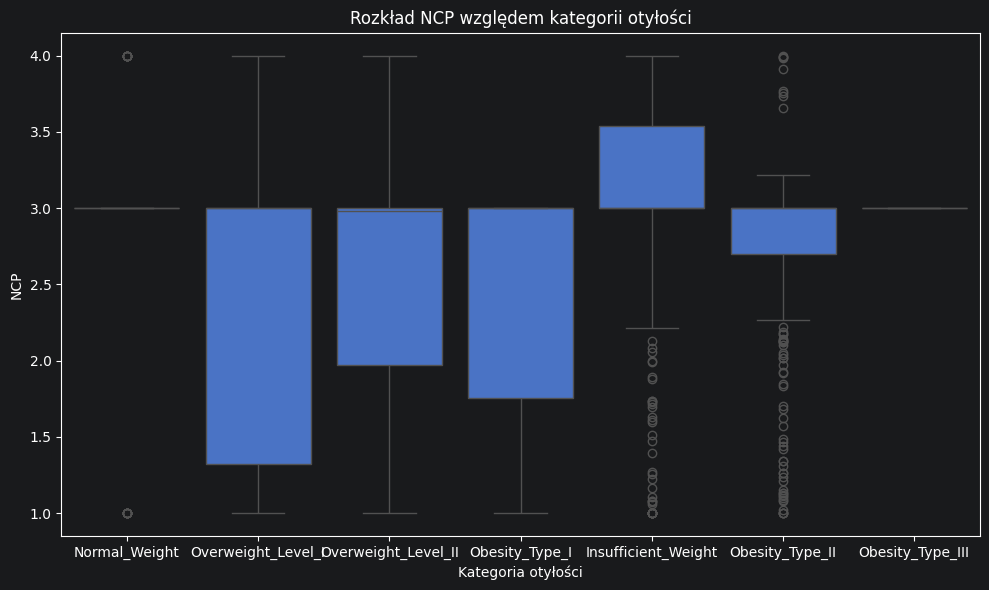

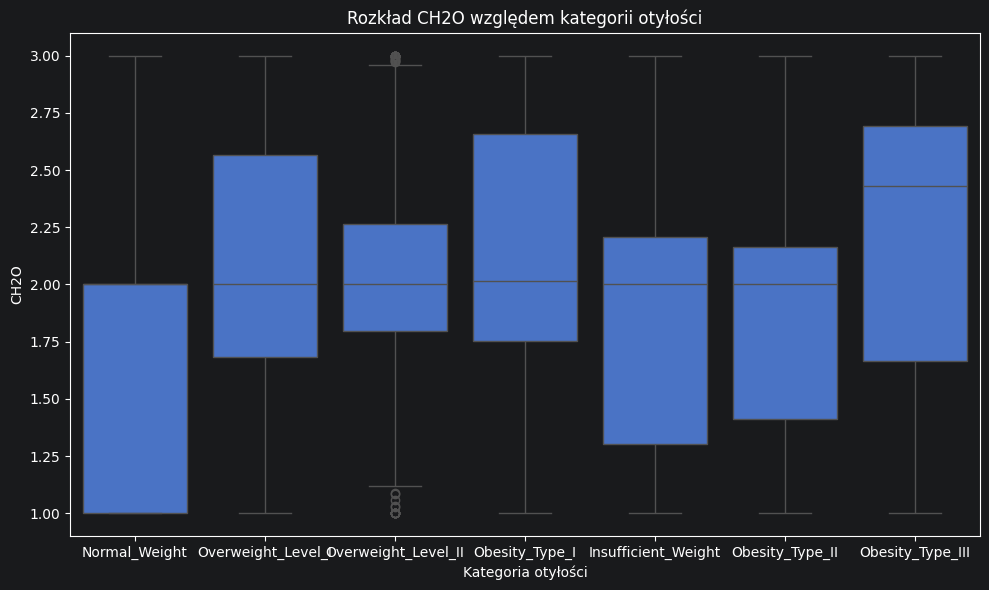

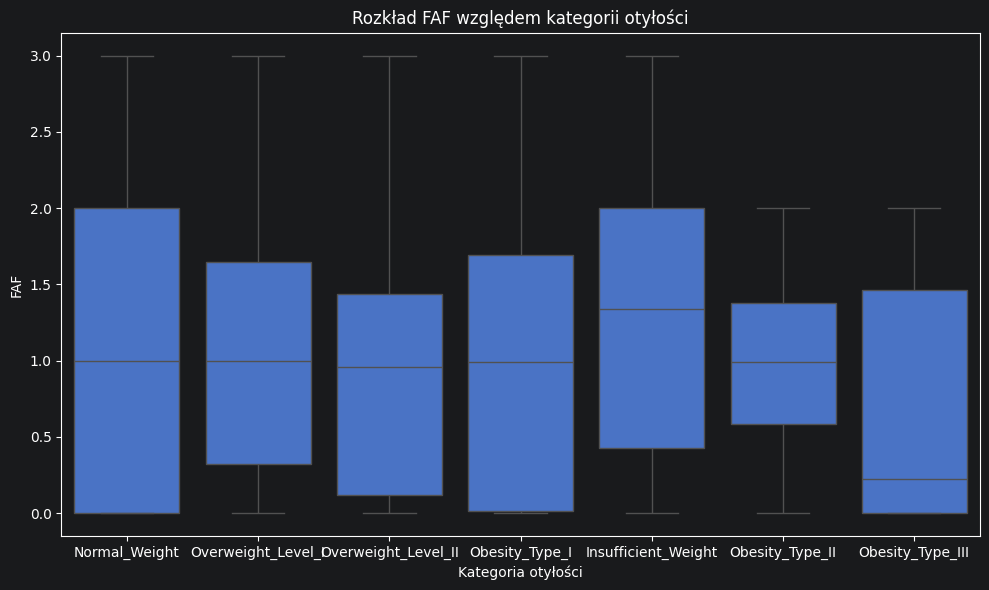

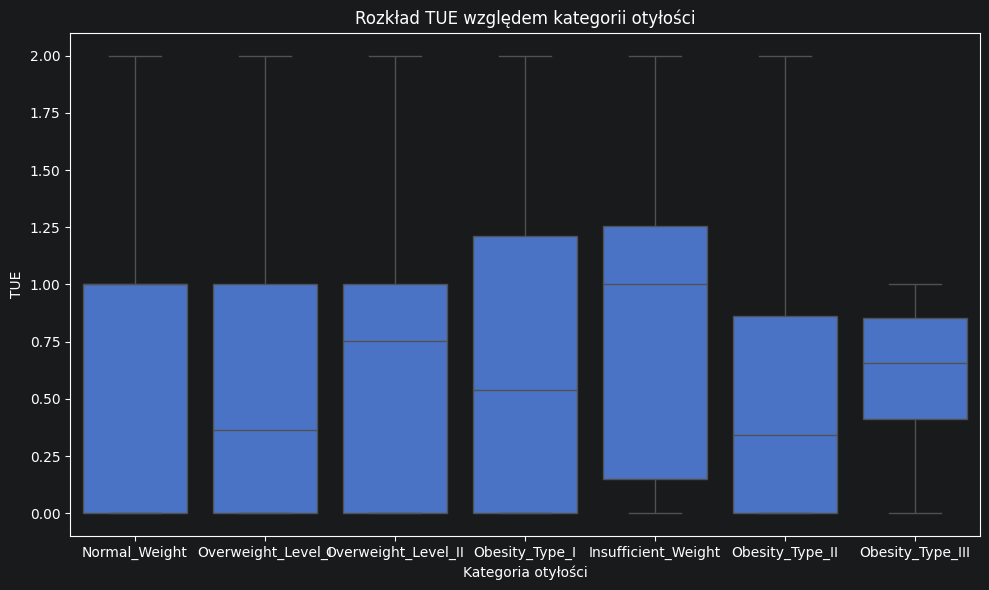

In [6]:
numerical_features = ['Age', 'Height', 'Weight', 'FCVC', 'NCP', 'CH2O', 'FAF', 'TUE']
for feature in numerical_features:
    plt.figure(figsize=(10, 6))
    sns.boxplot(data=df, x='NObeyesdad', y=feature)
    plt.title(f'Rozkład {feature} względem kategorii otyłości')
    plt.xlabel('Kategoria otyłości')
    plt.ylabel(feature)
    plt.tight_layout()
    plt.show()

0.9194694457603032


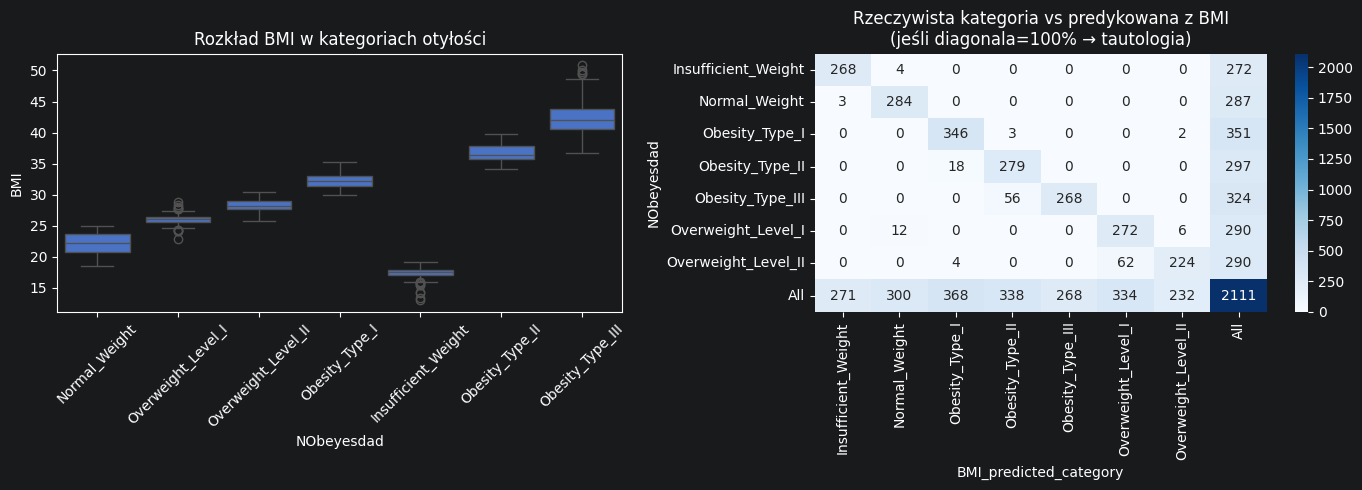

In [7]:
# %% Analiza tautologii: czy NObeyesdad powstaje z BMI?
# Jeśli tak — oznacza to data leakage, jeśli uczymy model na Height/Weight

df_original = df.copy()
# Oblicz BMI
df_original['BMI'] = df_original['Weight'] / ((df_original['Height']) ** 2)

# Funkcja do mapowania BMI na kategorie
def bmi_to_category(bmi):
    if bmi < 18.5:
        return 'Insufficient_Weight'
    elif bmi < 25.0:
        return 'Normal_Weight'
    elif bmi < 27.5:
        return 'Overweight_Level_I'
    elif bmi < 30.0:
        return 'Overweight_Level_II'
    elif bmi < 35.0:
        return 'Obesity_Type_I'
    elif bmi < 40.0:
        return 'Obesity_Type_II'
    else:
        return 'Obesity_Type_III'

# Utwórz kolumnę predykowaną z BMI
df_original['BMI_predicted_category'] = df_original['BMI'].apply(bmi_to_category)
agreement = (df_original['BMI_predicted_category']==df_original["NObeyesdad"]).sum()
print(agreement/len(df_original))
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Boxplot BMI vs NObeyesdad
sns.boxplot(data=df_original, x='NObeyesdad', y='BMI', ax=axes[0])
axes[0].set_title('Rozkład BMI w kategoriach otyłości')
axes[0].tick_params(axis='x', rotation=45)

# Heatmap: tabela przejścia (rzeczywista vs predykowana z BMI)
confusion_bmi = pd.crosstab(
    df_original['NObeyesdad'],
    df_original['BMI_predicted_category'],
    margins=True
)
sns.heatmap(confusion_bmi, annot=True, fmt='d', cmap='Blues', ax=axes[1])
axes[1].set_title('Rzeczywista kategoria vs predykowana z BMI\n(jeśli diagonala=100% → tautologia)')

plt.tight_layout()
plt.show()


In [8]:
#usunięcie wagi
df = df.drop("Weight",axis=1)

#odpowiednie zakodowanie cech kategorycznych
df['Gender'] = df['Gender'].map({'Female': 0, 'Male': 1})
df['family_history_with_overweight'] = df['family_history_with_overweight'].map({'no': 0, 'yes': 1})
df['FAVC'] = df['FAVC'].map({'no': 0, 'yes': 1})
df['CAEC'] = df['CAEC'].map({'no': 0, 'Sometimes': 1, 'Frequently': 2, 'Always': 3})
df['SMOKE'] = df['SMOKE'].map({'no': 0, 'yes': 1})
df['SCC'] = df['SCC'].map({'no': 0, 'yes': 1})
df['CALC'] = df['CALC'].map({'no': 0, 'Sometimes': 1, 'Frequently': 2, 'Always': 3})
df = pd.get_dummies(df, columns=['MTRANS'], drop_first=True)
df['NObeyesdad'] = df['NObeyesdad'].map({'Insufficient_Weight': 0, 'Normal_Weight': 1, 'Overweight_Level_I': 2, 'Overweight_Level_II': 3, 'Obesity_Type_I': 4, 'Obesity_Type_II': 5, 'Obesity_Type_III': 6})


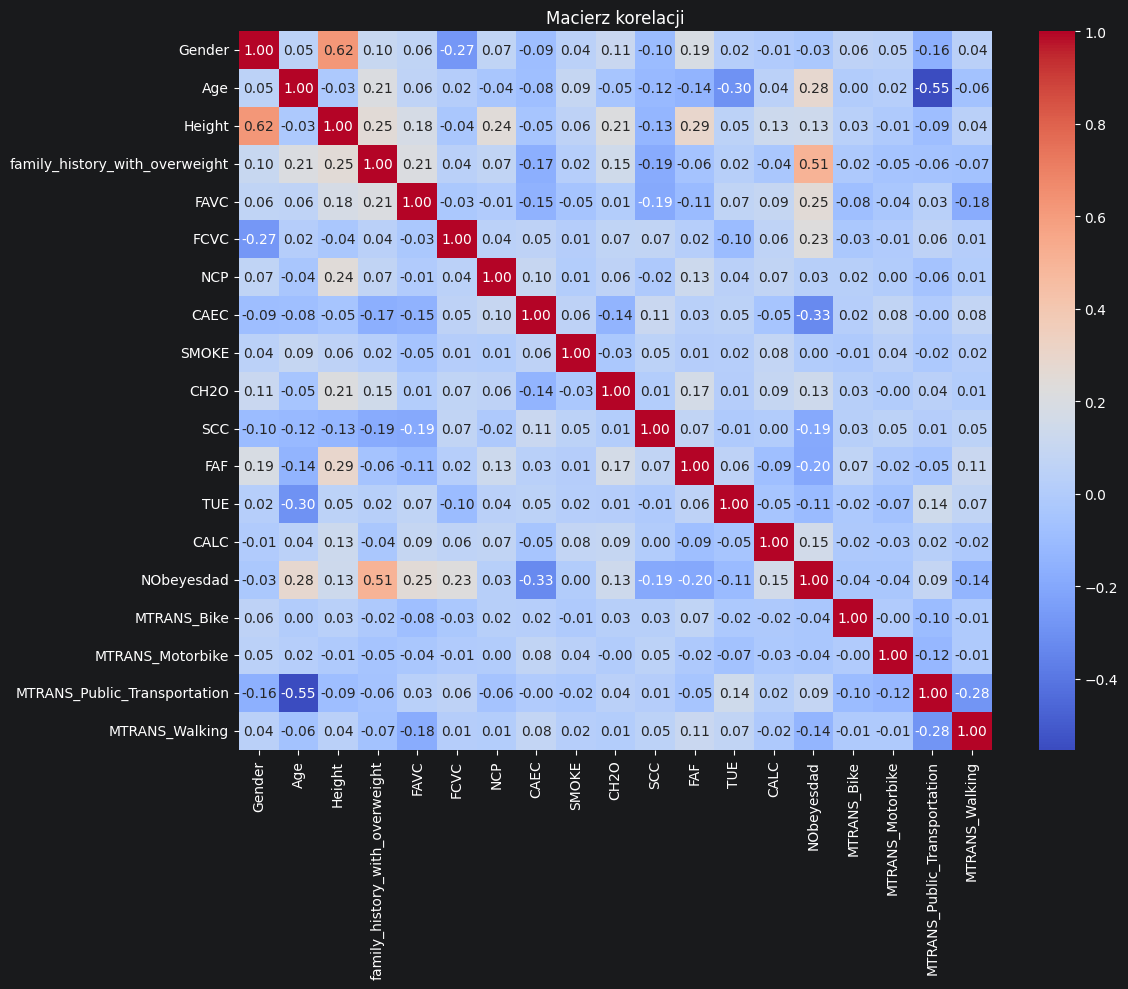

In [9]:
#sprawdzenie korelacji między cechami a celem
correlation_matrix = df.corr()
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Macierz korelacji')
plt.tight_layout()
plt.show()

In [ ]:
import time
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import BaggingClassifier, AdaBoostClassifier, GradientBoostingClassifier, StackingClassifier, VotingClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, recall_score, f1_score, precision_score, roc_auc_score
from scipy.stats import randint, uniform
# Przygotowanie zbioru do trenowania
y = df['NObeyesdad']
X = df.drop('NObeyesdad', axis=1)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=67)
# Standaryzacja cech numerycznych
numerical_features = ['Age', 'Height', 'FCVC', 'NCP', 'CH2O', 'FAF', 'TUE','CAEC','CALC']
scaler = StandardScaler()
X_train[numerical_features] = scaler.fit_transform(X_train[numerical_features])
X_test[numerical_features] = scaler.transform(X_test[numerical_features])


In [53]:
model_results = []

def evaluate_model(name, model, X_test, y_test):
    start_time = time.perf_counter()
    y_pred = model.predict(X_test)
    total = time.perf_counter() - start_time
    recall = recall_score(y_test, y_pred, average='macro')
    f1 = f1_score(y_test, y_pred, average='macro')
    acc = accuracy_score(y_test, y_pred)
    probs = model.predict_proba(X_test)
    confidences = probs.max(axis=1)
    mean_conf = confidences.mean()

    model_results.append({
        "model": name,
        "accuracy": acc,
        "macro_f1": f1,
        "macro_recall": recall,
        "mean_confidence": mean_conf,
        "predict_time_s": total,
    })

    print(f"=== Ewaluacja: {name} ===")
    print(f"Czułość (Macro Recall): {recall:.4f}")
    print(f"F1-Score (Macro):       {f1:.4f}")
    print(f"Dokładność (Accuracy):  {acc:.4f}")
    print(f"Czas predykcji (s):     {total:.6f}")
    print(f"Średnia confidence:     {mean_conf:.4f}")
    print("Raport klasyfikacji:")
    print(classification_report(y_test, y_pred))
    print()


In [44]:
#drzewo decyzyjne
dt_model = DecisionTreeClassifier(class_weight='balanced', random_state=67)
dt_params = {
    "max_depth": randint(3,15),
    "min_samples_split": randint(2,10),
    "criterion": ["gini", "entropy"],
    "min_samples_leaf": randint(1,10)
}

dt_rs = RandomizedSearchCV(
    estimator=dt_model,
    param_distributions=dt_params,
    n_iter=100,
    scoring='recall_macro',
    cv=3,
    n_jobs=-1,
    random_state=67,
    verbose=2
)
dt_rs.fit(X_train, y_train)
print(f"Najlepsze parametry: {dt_rs.best_params_}")
print(f"Najlepszy CV recall macro {dt_rs.best_score_}")

dt_best_model = dt_rs.best_estimator_
evaluate_model("Drzewo decyzyjne", dt_best_model, X_test, y_test)


Fitting 3 folds for each of 100 candidates, totalling 300 fits
Najlepsze parametry: {'criterion': 'gini', 'max_depth': 14, 'min_samples_leaf': 1, 'min_samples_split': 5}
Najlepszy CV recall macro 0.7309705904656294
=== Ewalucja: Drzewo decyzyjne ===
Czu?o?? (Macro Recall): 0.7731
F1-Score (Macro):       0.7731
Dok?adno?? (Accuracy):  0.7778
Czas predykcji (s):     0.004802
?rednia confidence:     0.9490
Raport klasyfikacji:
              precision    recall  f1-score   support

           0       0.76      0.83      0.80        54
           1       0.55      0.57      0.56        58
           2       0.62      0.64      0.63        58
           3       0.78      0.67      0.72        58
           4       0.81      0.81      0.81        70
           5       0.93      0.90      0.92        60
           6       0.97      0.98      0.98        65

    accuracy                           0.78       423
   macro avg       0.77      0.77      0.77       423
weighted avg       0.78      0

In [45]:
#regresja logistyczna
logreg_model = LogisticRegression(max_iter=1000, random_state=67,solver='saga', class_weight='balanced')
logreg_params = {
    "C": uniform(0.01, 10.0),
    "penalty": ["l1", "l2"],
}
logreg_rs = RandomizedSearchCV(
    estimator=logreg_model,
    param_distributions=logreg_params,
    n_iter=30,
    scoring='recall_macro',
    cv=3,
    n_jobs=-1,
    random_state=67,
    verbose=2
)
logreg_rs.fit(X_train, y_train)
print(f"Najlepsze parametry: {logreg_rs.best_params_}")
print(f"Najlepszy CV recall macro {logreg_rs.best_score_}")

logreg_best_model = logreg_rs.best_estimator_
evaluate_model("Regresja logistyczna", logreg_best_model, X_test, y_test)


Fitting 3 folds for each of 30 candidates, totalling 90 fits


C:\Users\ignac\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:1421: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(


Najlepsze parametry: {'C': np.float64(5.468514299349786), 'penalty': 'l1'}
Najlepszy CV recall macro 0.5679018690607601
=== Ewalucja: Regresja logistyczna ===
Czu?o?? (Macro Recall): 0.6018
F1-Score (Macro):       0.5880
Dok?adno?? (Accuracy):  0.6052
Czas predykcji (s):     0.003820
?rednia confidence:     0.5750
Raport klasyfikacji:
              precision    recall  f1-score   support

           0       0.54      0.69      0.61        54
           1       0.56      0.31      0.40        58
           2       0.53      0.52      0.52        58
           3       0.45      0.38      0.41        58
           4       0.55      0.49      0.52        70
           5       0.57      0.85      0.68        60
           6       0.97      0.98      0.98        65

    accuracy                           0.61       423
   macro avg       0.60      0.60      0.59       423
weighted avg       0.60      0.61      0.59       423




C:\Users\ignac\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


In [46]:
#bagging

bag_tree_model = BaggingClassifier(estimator=DecisionTreeClassifier(class_weight='balanced'), random_state=67)
bag_tree_params = {
    'n_estimators': randint(10, 100),
    'bootstrap': [True, False],
    'bootstrap_features': [True, False],
    'estimator__max_depth': [3, 5, 10, None]
}

bag_tree_rs = RandomizedSearchCV(
    estimator=bag_tree_model,
    param_distributions=bag_tree_params,
    n_iter=20,
    scoring='recall_macro',
    cv=3,
    n_jobs=-1,
    random_state=67,
    verbose=1
)

bag_tree_rs.fit(X_train, y_train)

print(f"\nNajlepsze parametry: {bag_tree_rs.best_params_}")
bag_tree_best_model = bag_tree_rs.best_estimator_
evaluate_model("Bagging (Drzewa Decyzyjne)", bag_tree_best_model, X_test, y_test)


Fitting 3 folds for each of 20 candidates, totalling 60 fits

Najlepsze parametry: {'bootstrap': True, 'bootstrap_features': True, 'estimator__max_depth': None, 'n_estimators': 90}
=== Ewalucja: Bagging (Drzewa Decyzyjne) ===
Czu?o?? (Macro Recall): 0.8926
F1-Score (Macro):       0.8931
Dok?adno?? (Accuracy):  0.8936
Czas predykcji (s):     0.039257
?rednia confidence:     0.6920
Raport klasyfikacji:
              precision    recall  f1-score   support

           0       0.92      0.91      0.92        54
           1       0.73      0.90      0.81        58
           2       0.98      0.81      0.89        58
           3       0.86      0.83      0.84        58
           4       0.92      0.87      0.90        70
           5       0.89      0.95      0.92        60
           6       0.98      0.98      0.98        65

    accuracy                           0.89       423
   macro avg       0.90      0.89      0.89       423
weighted avg       0.90      0.89      0.89       423


In [47]:
#bagging regresja

bag_logreg_model = BaggingClassifier(estimator=LogisticRegression(max_iter=1000,class_weight='balanced'), random_state=67)
bag_logreg_params = {
    'n_estimators': randint(10, 50),
    'bootstrap': [True, False],
    'bootstrap_features': [True, False],
}

bag_logreg_rs = RandomizedSearchCV(
    estimator=bag_logreg_model,
    param_distributions=bag_logreg_params,
    n_iter=20,
    scoring='recall_macro',
    cv=3,
    n_jobs=-1,
    random_state=67,
    verbose=1
)

bag_logreg_rs.fit(X_train, y_train)

print(f"\nNajlepsze parametry: {bag_logreg_rs.best_params_}")
bag_logreg_best_model = bag_logreg_rs.best_estimator_
evaluate_model("Bagging (Regresja Logistyczna)", bag_logreg_best_model, X_test, y_test)


Fitting 3 folds for each of 20 candidates, totalling 60 fits

Najlepsze parametry: {'bootstrap': True, 'bootstrap_features': False, 'n_estimators': 45}
=== Ewalucja: Bagging (Regresja Logistyczna) ===
Czu?o?? (Macro Recall): 0.5966
F1-Score (Macro):       0.5835
Dok?adno?? (Accuracy):  0.6005
Czas predykcji (s):     0.024813
?rednia confidence:     0.5482
Raport klasyfikacji:
              precision    recall  f1-score   support

           0       0.56      0.65      0.60        54
           1       0.50      0.29      0.37        58
           2       0.52      0.52      0.52        58
           3       0.48      0.41      0.44        58
           4       0.57      0.49      0.52        70
           5       0.55      0.83      0.66        60
           6       0.96      0.98      0.97        65

    accuracy                           0.60       423
   macro avg       0.59      0.60      0.58       423
weighted avg       0.59      0.60      0.59       423




In [48]:
#ada boost

ada_model = AdaBoostClassifier(random_state=67)
ada_params = {
    'n_estimators': randint(50, 250),
    'learning_rate':uniform(0.01,1.0),
    'estimator': [
        DecisionTreeClassifier(max_depth=1, class_weight='balanced'),
        DecisionTreeClassifier(max_depth=2, class_weight='balanced'),
        DecisionTreeClassifier(max_depth=3, class_weight='balanced'),
        DecisionTreeClassifier(max_depth=4, class_weight='balanced'),
        LogisticRegression(max_iter=1000, class_weight='balanced')
    ],
}

ada_rs = RandomizedSearchCV(
    estimator=ada_model,
    param_distributions=ada_params,
    n_iter=20,
    scoring='recall_macro',
    cv=3,
    n_jobs=-1,
    random_state=67,
    verbose=1
)

ada_rs.fit(X_train, y_train)

print(f"\nNajlepsze parametry: {ada_rs.best_params_}")
ada_best_model = ada_rs.best_estimator_
evaluate_model("AdaBoost", ada_best_model, X_test, y_test)


Fitting 3 folds for each of 20 candidates, totalling 60 fits

Najlepsze parametry: {'estimator': DecisionTreeClassifier(class_weight='balanced', max_depth=4), 'learning_rate': np.float64(0.7148316371069013), 'n_estimators': 224}
=== Ewalucja: AdaBoost ===
Czu?o?? (Macro Recall): 0.8207
F1-Score (Macro):       0.8218
Dok?adno?? (Accuracy):  0.8227
Czas predykcji (s):     0.100452
?rednia confidence:     0.1473
Raport klasyfikacji:
              precision    recall  f1-score   support

           0       0.92      0.87      0.90        54
           1       0.72      0.67      0.70        58
           2       0.72      0.79      0.75        58
           3       0.72      0.79      0.75        58
           4       0.80      0.81      0.81        70
           5       0.89      0.82      0.85        60
           6       1.00      0.98      0.99        65

    accuracy                           0.82       423
   macro avg       0.83      0.82      0.82       423
weighted avg       0.83 

In [49]:
gb_model = GradientBoostingClassifier(random_state=67)

gb_params = {

    'n_estimators': randint(50, 300),
    'learning_rate': uniform(0.01, 0.99),
    'max_depth': randint(2, 7),
    'subsample': uniform(0.6, 0.4)
}

gb_rs = RandomizedSearchCV(
    estimator=gb_model,
    param_distributions=gb_params,
    n_iter=30,
    scoring='recall_macro',
    cv=3,
    n_jobs=-1,
    random_state=67,
    verbose=1
)

gb_rs.fit(X_train, y_train)

print(f"\nNajlepsze parametry: {gb_rs.best_params_}")
gb_best_model = gb_rs.best_estimator_

evaluate_model("Gradient Boosting", gb_best_model, X_test, y_test)


Fitting 3 folds for each of 30 candidates, totalling 90 fits

Najlepsze parametry: {'learning_rate': np.float64(0.18272273780083917), 'max_depth': 6, 'n_estimators': 236, 'subsample': np.float64(0.6096189216580036)}
=== Ewalucja: Gradient Boosting ===
Czu?o?? (Macro Recall): 0.8727
F1-Score (Macro):       0.8740
Dok?adno?? (Accuracy):  0.8747
Czas predykcji (s):     0.038280
?rednia confidence:     0.9728
Raport klasyfikacji:
              precision    recall  f1-score   support

           0       0.92      0.89      0.91        54
           1       0.69      0.83      0.75        58
           2       0.88      0.79      0.84        58
           3       0.90      0.79      0.84        58
           4       0.88      0.87      0.88        70
           5       0.90      0.95      0.93        60
           6       0.97      0.98      0.98        65

    accuracy                           0.87       423
   macro avg       0.88      0.87      0.87       423
weighted avg       0.88     

In [50]:
#Voting
svm_model = SVC(kernel='rbf', gamma='auto',class_weight='balanced',random_state=67,probability=True)
svm_model.fit(X_train, y_train)
trained_estimators = [
    ('bagging', bag_tree_best_model),
    ('svm', svm_model),
    ('gb', gb_best_model),
]
voting_model = VotingClassifier(estimators=trained_estimators, voting='soft')
voting_model.fit(X_train, y_train)
evaluate_model('voting_model', voting_model, X_test, y_test)


=== Ewalucja: voting_model ===
Czu?o?? (Macro Recall): 0.8801
F1-Score (Macro):       0.8818
Dok?adno?? (Accuracy):  0.8818
Czas predykcji (s):     0.180595
?rednia confidence:     0.7731
Raport klasyfikacji:
              precision    recall  f1-score   support

           0       0.92      0.89      0.91        54
           1       0.69      0.84      0.76        58
           2       0.94      0.81      0.87        58
           3       0.92      0.81      0.86        58
           4       0.88      0.87      0.88        70
           5       0.89      0.95      0.92        60
           6       0.97      0.98      0.98        65

    accuracy                           0.88       423
   macro avg       0.89      0.88      0.88       423
weighted avg       0.89      0.88      0.88       423




In [51]:
#stacking
level_0_estimators = trained_estimators
level_1_estimator = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=67)
stacking_model = StackingClassifier(estimators=level_0_estimators,final_estimator=level_1_estimator, cv = 5, n_jobs=-1)

stacking_model.fit(X_train, y_train)
evaluate_model('stacking_model', stacking_model, X_test, y_test)

=== Ewalucja: stacking_model ===
Czu?o?? (Macro Recall): 0.8844
F1-Score (Macro):       0.8858
Dok?adno?? (Accuracy):  0.8865
Czas predykcji (s):     0.236079
?rednia confidence:     0.8751
Raport klasyfikacji:
              precision    recall  f1-score   support

           0       0.94      0.91      0.92        54
           1       0.70      0.84      0.77        58
           2       0.92      0.81      0.86        58
           3       0.87      0.81      0.84        58
           4       0.91      0.90      0.91        70
           5       0.90      0.93      0.92        60
           6       0.98      0.98      0.98        65

    accuracy                           0.89       423
   macro avg       0.89      0.88      0.89       423
weighted avg       0.89      0.89      0.89       423




,model,accuracy,macro_f1,macro_recall,mean_confidence,predict_time_s
2,Bagging (Drzewa Decyzyjne),0.893617,0.893145,0.892562,0.691954,0.039257
7,stacking_model,0.886525,0.885850,0.884410,0.875110,0.236079
6,voting_model,0.881797,0.881751,0.880064,0.773104,0.180595
5,Gradient Boosting,0.874704,0.873955,0.872675,0.972835,0.038280
4,AdaBoost,0.822695,0.821828,0.820651,0.147348,0.100452
0,Drzewo decyzyjne,0.777778,0.773109,0.773078,0.948985,0.004802
1,Regresja logistyczna,0.605201,0.588047,0.601773,0.575015,0.003820
3,Bagging (Regresja Logistyczna),0.600473,0.583510,0.596564,0.548232,0.024813


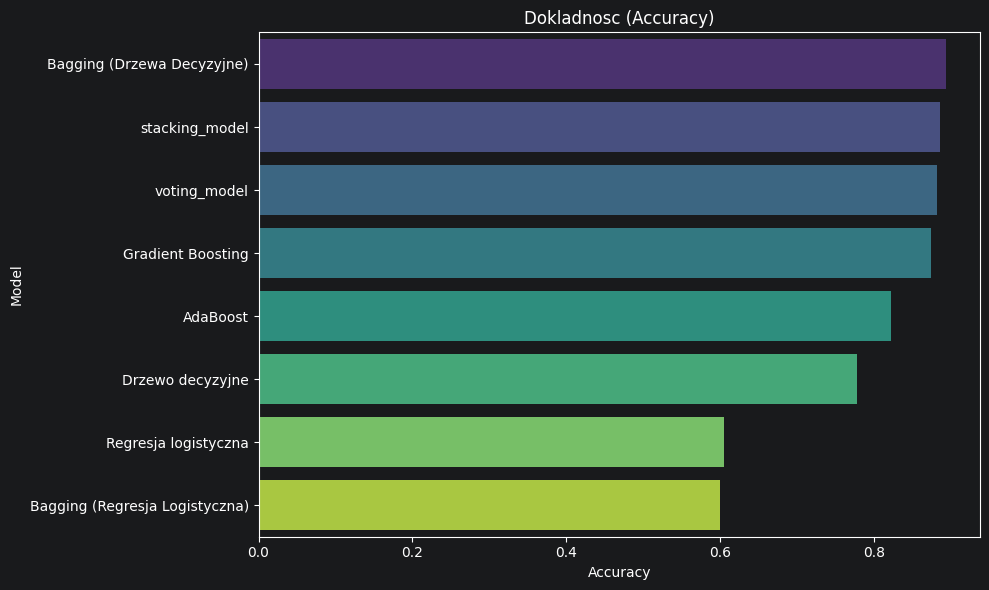

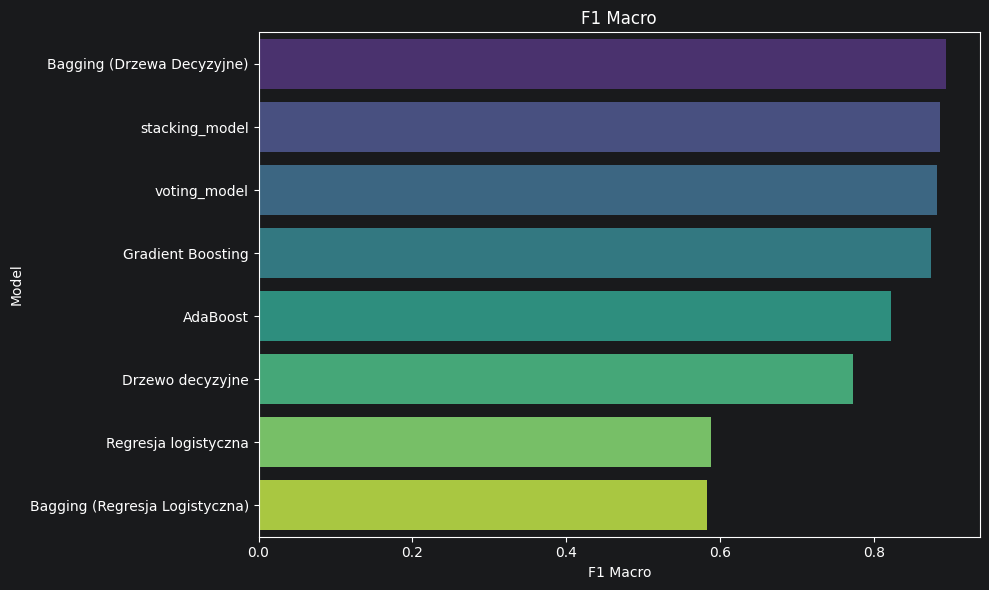

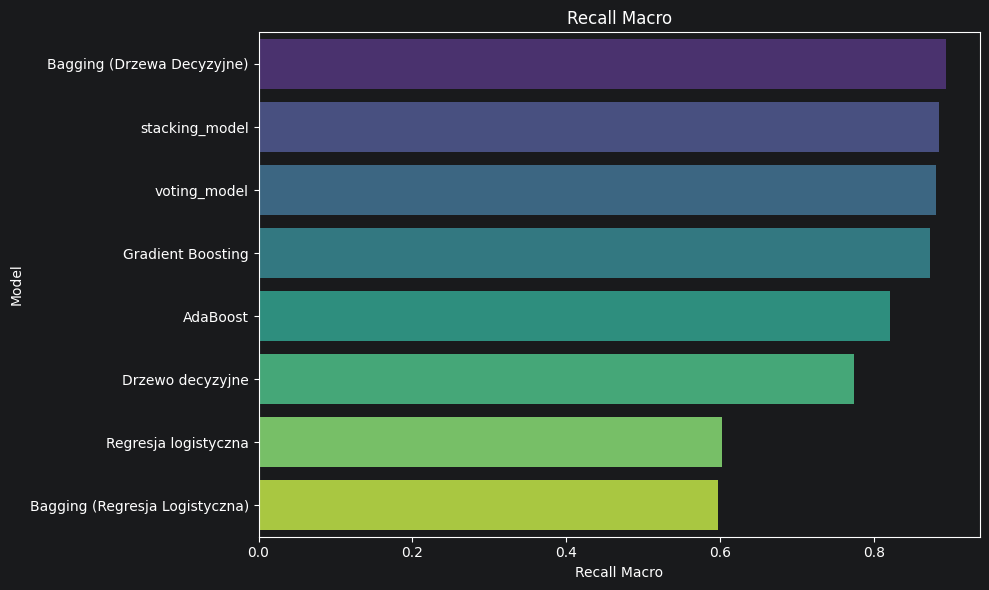

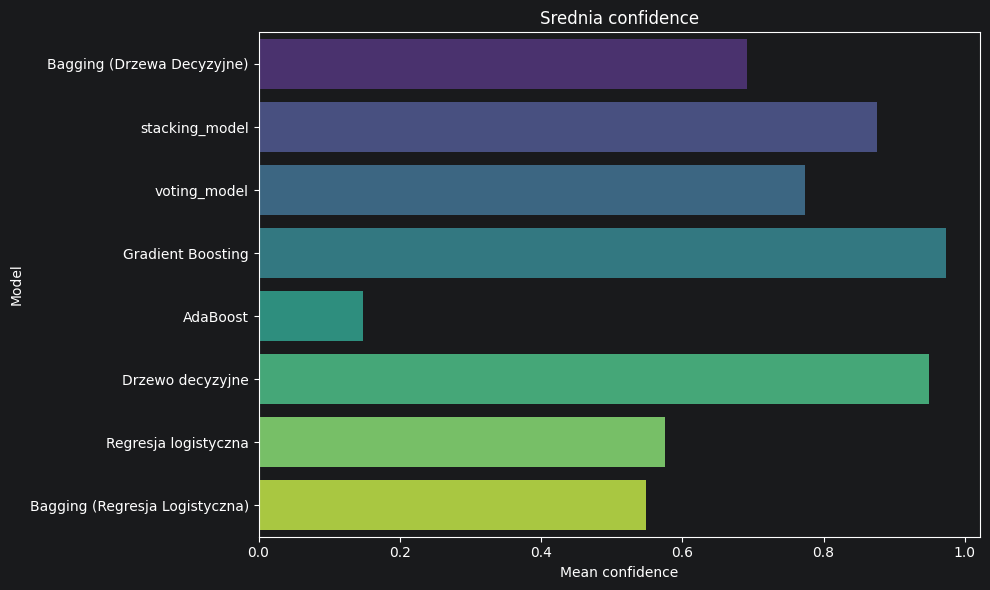

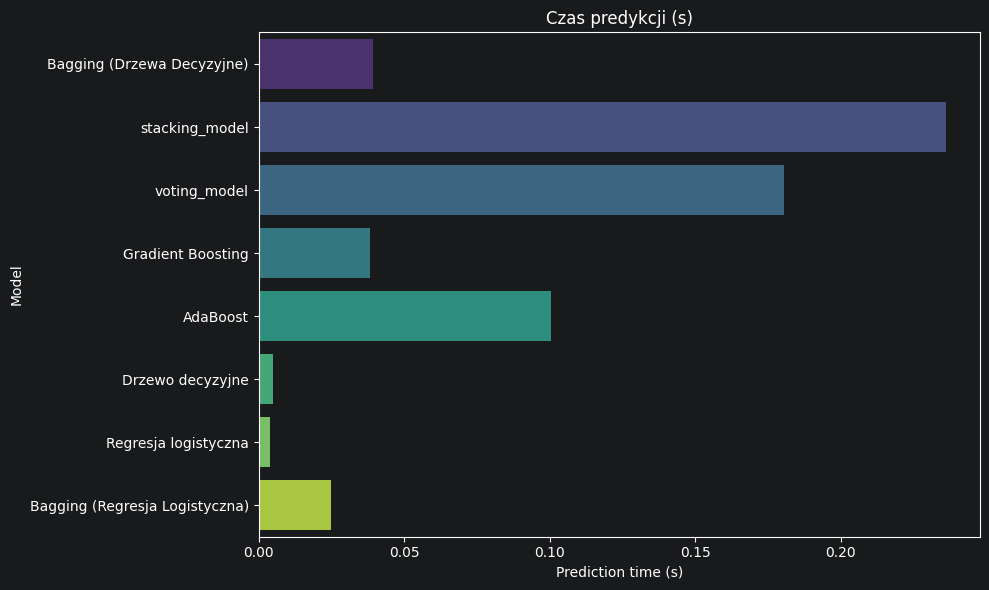

In [52]:
# Porownanie modeli: metryki, confidence, czas
results_df = pd.DataFrame(model_results)
results_df = results_df.sort_values(by='accuracy', ascending=False)
display(results_df)

plt.figure(figsize=(10, 6))
sns.barplot(data=results_df, x='accuracy', y='model', palette='viridis')
plt.title('Dokladnosc (Accuracy)')
plt.xlabel('Accuracy')
plt.ylabel('Model')
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 6))
sns.barplot(data=results_df, x='macro_f1', y='model', palette='viridis')
plt.title('F1 Macro')
plt.xlabel('F1 Macro')
plt.ylabel('Model')
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 6))
sns.barplot(data=results_df, x='macro_recall', y='model', palette='viridis')
plt.title('Recall Macro')
plt.xlabel('Recall Macro')
plt.ylabel('Model')
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 6))
sns.barplot(data=results_df, x='mean_confidence', y='model', palette='viridis')
plt.title('Srednia confidence')
plt.xlabel('Mean confidence')
plt.ylabel('Model')
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 6))
sns.barplot(data=results_df, x='predict_time_s', y='model', palette='viridis')
plt.title('Czas predykcji (s)')
plt.xlabel('Prediction time (s)')
plt.ylabel('Model')
plt.tight_layout()
plt.show()


## Wnioski dotyczące wdrożenia

Jeśli założylibyśmy, że w danych mamy dostępną wagę, predykcja klas otyłości była by bardzo prosta. Wynika to z tego, że klasy otyłości były przypisywane na podstawie BMI, a te przykłady które nie mieszczą się w sztywnych widełkach, wynikają z wykorzystania metody oversamplingu SMOTE. Prosta predykcja oparta na policzeniu BMI i przypisaniu klasy daje około 92% dokładności, przy czym przytłaczająca większość poczynionych błędów jest na granicy klas do sie bie podobnych (np. Obesity II i III). Stąd, w przypadku posiadania danych dot. wagi najlepiej, aby lekarz miał po prostu kalkulator. Jeśli jednak założymy, że w danych nie mamy wagi, najlepszym modelem do wdrożenia okazuje się bagging oparty na drzewach decyzyjnych. Osiąga on najlepszy recall, f1 etc. Czas predykcji jest akceptowalnie długi, dużo krótszy niż przy uzyskującym podobne wyniki np. stackingu. Co prawda nie osiąga najwyższych wyników pewności, ale są one akceptowalne. Generalnie w tym zadaniu dużo lepszymi okazały się rozwiązania oparte na drzewach, w porównaniu z tymi opartymi na regresji logistycznej.


 ## Zadanie 2: Grzybobranie

### Wprowadzenie

Mieszkasz w "Warszawce". Ostatnio całe miasto opanował nowy trend – grzybobranie! Czy wiedziałeś, że grzybów nie trzeba kupować w sklepie? Rosną w lesie, zupełnie za darmo i E-KO-LO-GICZ-NIE.

Postanawiasz wybrać się do "mało znanego" miejsca – lasu pod Konstancinem-Jeziorną. Niestety, na miejscu okazuje się, że o grzybach nie masz zielonego pojęcia, a odróżnienie borowika od muchomora stanowi dla Ciebie ogromne wyzwanie. Już masz się poddać, ale nagle słyszysz za sobą podniesiony głos:

– Radziu, nie mów do mnie teraz!

Obracasz się i widzisz miło wyglądającą rodzinkę.

<img src="img.jpg" width="400" height="400" />

(Źródło: <a href="https://www.instagram.com/p/COLCA3RHoni/">instagram m_rozenek</a>)

Skądś ich kojarzysz (może z *morning matcha rave*?), ale nie to jest teraz najważniejsze. Widzisz, że próbują rozszyfrować **ZAAWANSOWANY ATLAS GRZYBÓW**. Postanawiasz dołączyć do zadania, ale szybko okazuje się, że rozumiesz z niego tyle co nic. Zamiast zdjęć i opisów, atlas zawiera wyłącznie tabele przedstawiające cechy grzybów. Sprawdzanie całej tabeli w poszukiwaniu odpowiedniego dopasowania do zaobserwowanych parametrów okazu od razu wydaje Ci się marnowaniem czasu. Wykorzystujesz więc wiedzę nabytą na zajęciach ze Sztucznej Inteligencji i postanawiasz stworzyć model uczenia maszynowego klasyfikujący grzyby.

Pamiętaj – błąd algorytmu oznacza poważne zatrucie. Chociaż masz dostęp do potężnych narzędzi, bateria w Twoim telefonie jest na wyczerpaniu, a każda sekunda pracy procesora jest na wagę złota. Musisz zdecydować, jaki model będzie adekwatny do zadania – na tyle precyzyjny, by przeżyć, a zarazem wystarczająco "lekki", by zadziałał w lesie.

### Polecenia:

1. **Wykonaj analizę eksploracyjną (EDA)** [zbioru danych o grzybach (UCI ID: 73)](https://archive.ics.uci.edu/dataset/73/mushroom).
2. Według własnego uznania **wybierz modele** i **wyucz** je. Wykorzystaj zdobytą dotychczas wiedzę. Przynajmniej jednym z testowanych modeli powinien być model zespołowy (ensemble).
3. **Zwaliduj wyuczone modele**. Pamiętaj, że pomyłka może skończyć się zatruciem, więc warto byłoby móc zinterpretować i zrozumieć decyzje modelu.
4. **Zapisz wnioski**.

Przy realizacji poleceń pamiętaj o specyficznym charakterze i ograniczeniach zadania.